<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/02_Vectors_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Vectors, Part 1**

This notebook covers Vectors, Part 1:

1. Creating and Visualizing Vectors in NumPy
2. Geometry of Vectors
3. Operations on Vectors
4. Vector Magnitude and Unit Vectors
5. The Vector Dot Product
6. Other Vector Multiplications
7. Orthogonal Vector Decomposition

## **1. Creating and Visualizing Vectors in NumPy**

In linear algebra, a vector is an ordered list of numbers. Two fundamental characteristics define every vector:

- Dimensionality: The number of elements in the vector. A vector with N elements lives in ℝᴺ.
- Orientation: Whether the vector is arranged as a column (tall) or a row (flat).

By convention in linear algebra, vectors are assumed to be column vectors unless otherwise stated. Row vectors are written as `vᵀ`, where the superscript T denotes the transpose operation.

There is an important terminological mismatch between mathematics and Python. In mathematics, the *dimensionality* of a vector is the number of elements it contains. In Python, the *dimensionality* refers to the number of geometric dimensions used to store the array (i.e., whether it's 1D, 2D, etc.), regardless of how many elements it has. Cohen flags this explicitly to prevent confusion.

Below are four different ways to create vectors in Python:

In [1]:
import numpy as np

# Four ways to represent a vector in Python
asList  = [1, 2, 3]
asArray = np.array([1, 2, 3])       # 1D array — no explicit orientation
rowVec  = np.array([[1, 2, 3]])     # row vector — shape (1, 3)
colVec  = np.array([[1], [2], [3]]) # column vector — shape (3, 1)

print(f'asList:  {np.shape(asList)}')
print(f'asArray: {asArray.shape}')
print(f'rowVec:  {rowVec.shape}')
print(f'colVec:  {colVec.shape}')

asList:  (3,)
asArray: (3,)
rowVec:  (1, 3)
colVec:  (3, 1)


## **2. Geometry of Vectors**

The geometric interpretation of a vector is a straight line with a specific magnitude (length) and direction (angle, measured from the positive x-axis). A vector has a tail (where it starts) and a head (where it ends, often indicated with an arrow).

It is important to distinguish between a vector and a coordinate: a vector is not a point in space, but a displacement. However, when a vector is placed in standard position — with its tail at the origin — its head does correspond to a specific geometric coordinate. This equivalence between vectors and coordinates in standard position is used constantly throughout the book.

The algebraic and geometric interpretations are two sides of the same coin: the geometric view is more useful in physics and engineering (e.g., representing forces), while the algebraic view is more natural for data science (e.g., representing data observations).

## **3. Operations on Vectors**

### **3.1 Adding Two Vectors**

Vector addition is performed element-wise: corresponding elements from two vectors of the same dimensionality and orientation are added together. The result is a new vector of the same dimensionality.

Geometrically, adding two vectors means placing the tail of one vector at the head of the other. The resulting sum vector goes from the tail of the first to the head of the second.

In [2]:
v = np.array([4, 5, 6])
w = np.array([10, 20, 30])
u = np.array([0, 3, 6, 9])

vPlusW = v + w
print(f'v + w = {vPlusW}')

# This will raise an error because dimensions are mismatched:
# uPlusW = u + w

v + w = [14 25 36]


Adding a row vector to a column vector in Python does *not* produce an error. Instead, Python applies broadcasting — repeating each vector to fill in dimensions — which produces a matrix output. This demonstrates why vector orientation is important.

In [3]:
# Broadcasting example: adding a row and a column vector
v = np.array([[4, 5, 6]])    # row vector, shape (1, 3)
w = np.array([[10, 20, 30]]).T  # column vector, shape (3, 1)
print(v + w)

[[14 15 16]
 [24 25 26]
 [34 35 36]]


### **3.2 Vector-Scalar Multiplication**

A scalar in linear algebra is a standalone number (not embedded in a vector or matrix), typically denoted by lowercase Greek letters like α or λ. Multiplying a vector by a scalar is straightforward: multiply every element of the vector by the scalar.

Geometrically, scalars scale vectors without changing their direction — that is where the name comes from. The exception is a negative scalar, which flips the vector 180°. This can be interpreted as the vector still pointing along the same infinite line through the origin, just in the opposite direction.

An important subtlety: in Python, the data type of your vector matters for scalar multiplication.

In [4]:
s = 2
a = [3, 4, 5]        # as Python list
b = np.array(a)      # as NumPy array

print(a * s)   # List repetition — NOT scalar multiplication!
print(b * s)   # Correct: element-wise scalar multiplication

[3, 4, 5, 3, 4, 5]
[ 6  8 10]


### **3.3 Scalar-Vector Addition**

Formally, adding a scalar to a vector is not defined in classical linear algebra (they are different mathematical objects). However, Python allows this via broadcasting — the scalar is added to each element of the vector. This is occasionally useful in practice.

In [5]:
s = 2
v = np.array([3, 6])
print(s + v)  # Output: [5, 8] — scalar added to each element

[5 8]


### **3.4 Transpose**

The transpose operation swaps the row and column indices of a mathematical object. For vectors, this means converting a column vector to a row vector and vice versa. The formal definition is: if element `m_{i,j}` exists in a matrix (or vector), then in the transpose, that element appears at position `m_{j,i}`.

An important rule: transposing twice returns the original vector — `vᵀᵀ = v`. This seemingly trivial observation is actually the key to several important proofs later, including the construction of symmetric covariance matrices and the reason PCA corresponds to an orthogonal rotation of the data space.

### **3.5 Vector Broadcasting in Python**

Broadcasting is a Python-specific operation (not part of classical linear algebra theory) that repeats an operation multiple times between one vector and each element of another. It is extremely useful for efficient and compact numerical computations.

In [6]:
v = np.array([[1, 2, 3]]).T  # column vector, shape (3, 1)
w = np.array([[10, 20]])     # row vector, shape (1, 2)
print(v + w)  # Broadcasting produces a (3, 2) matrix

[[11 21]
 [12 22]
 [13 23]]


## **4. Vector Magnitude and Unit Vectors**

The magnitude (also called the norm or geometric length) of a vector is the Euclidean distance from its tail to its head. It is computed as the square root of the sum of squared elements:

$$\|\mathbf{v}\| = \sqrt{\sum_{i=1}^{n} v_i^2}$$

Note: in Python, `len(v)` returns the *mathematical dimensionality* (number of elements), while `np.linalg.norm(v)` returns the *geometric length* (magnitude).

A unit vector has a magnitude of exactly 1, and is denoted `v̂`. Any non-zero vector can be converted to a unit vector by dividing by its norm:

$$\hat{\mathbf{v}} = \frac{1}{\|\mathbf{v}\|} \mathbf{v}$$

The one exception is the zeros vector — it has magnitude 0 and no direction, so it has no associated unit vector.

In [7]:
v = np.array([1, 2, 3, 7, 8, 9])

v_dim = len(v)                  # mathematical dimensionality
v_mag = np.linalg.norm(v)       # geometric magnitude / norm

print(f'Dimensionality: {v_dim}')
print(f'Magnitude:      {v_mag:.4f}')

Dimensionality: 6
Magnitude:      14.4222


## **5. The Vector Dot Product**

The dot product (also called the inner product) is one of the most important operations in all of linear algebra. It is the atomic computational unit from which convolution, correlation, the Fourier transform, matrix multiplication, and countless other algorithms are built.

The dot product between two vectors of the same dimensionality is computed as element-wise multiplication followed by summation:

$$\delta = \sum_{i=1}^{n} a_i b_i$$

The result is a single scalar — a number that encodes the relationship between the two vectors.

### **Geometric Interpretation**

There is also a geometric definition: the dot product equals the product of the two vector magnitudes scaled by the cosine of the angle between them:

$$\alpha = \cos(\theta_{v,w}) \|v\| \|w\|$$

This geometric definition reveals something profound: the sign of the dot product is determined entirely by the angle between the vectors. Specifically:
- Positive angle (< 90°): positive dot product
- Exactly 90° (orthogonal vectors): dot product = 0 ← *memorize this*
- Obtuse angle (> 90°): negative dot product

The equivalence between orthogonality and zero dot product is one of the most important facts in linear algebra and will be used throughout the book.

In [8]:
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7, 8])

# Compute dot product
print(np.dot(v, w))   # Expected: 1*5 + 2*6 + 3*7 + 4*8 = 70

# Dot product is distributive: a^T(b + c) = a^T b + a^T c
a = np.array([0, 1, 2])
b = np.array([3, 5, 8])
c = np.array([13, 21, 34])

res1 = np.dot(a, b + c)
res2 = np.dot(a, b) + np.dot(a, c)
print(f'Distributive property: {res1} == {res2} → {res1 == res2}')

# Scalar multiplying one vector scales the dot product
s = 10
print(f'Original dot product:  {np.dot(v, w)}')
print(f'After scaling v by 10: {np.dot(s * v, w)}')

70
Distributive property: 110 == 110 → True
Original dot product:  70
After scaling v by 10: 700


## **6. Other Vector Multiplications**

### **6.1 Hadamard Multiplication**

Hadamard multiplication is simply element-wise multiplication of two vectors of the *same dimensionality*. The result is a new vector, not a scalar. It is denoted using the symbol ⊙.

In [9]:
a = np.array([5, 4, 8, 2])
b = np.array([1, 0, 0.5, -1])
print(a * b)  # Hadamard product — element-wise multiplication

[ 5.  0.  4. -2.]


### 6.2 Outer Product

The outer product of a column vector and a row vector produces a matrix. Each row in the result is the row vector scalar multiplied by the corresponding element of the column vector. The outer product is denoted `vwᵀ` (note the transpose is on the *second* vector, unlike the dot product `vᵀw`). The two vectors in an outer product may have *different* dimensionalities.

This subtle notational difference — `vᵀw` for dot product versus `vwᵀ` for outer product — will make complete sense once matrix multiplication is introduced in Chapter 5.

In [10]:
v = np.array([1, 2, 3])
w = np.array([4, 5])
print(np.outer(v, w))  # 3x2 matrix

[[ 4  5]
 [ 8 10]
 [12 15]]


## **7. Orthogonal Vector Decomposition**

Orthogonal vector decomposition is one of the most important concepts in this chapter and serves as the foundation for least squares regression, QR decomposition, and PCA. The goal is to decompose a target vector `t` into two components with respect to a reference vector `r`:

1. A component parallel to `r`: `t‖r`
2. A component perpendicular (orthogonal) to `r`: `t⊥r`

These two components must sum to the original vector: `t = t‖r + t⊥r`

### **Deriving the Parallel Component**

We want to find the scalar `β` such that `βr` is the closest point on `r` to the head of `t`. The key geometric insight is that the minimum-distance projection from `t` to `r` is always *perpendicular* to `r`. This means `(t - βr) ⊥ r`, so their dot product is zero:

$$\mathbf{r}^T(\mathbf{t} - \beta\mathbf{r}) = 0$$

Solving for `β`:

$$\beta = \frac{\mathbf{r}^T \mathbf{t}}{\mathbf{r}^T \mathbf{r}}$$

The parallel component is then: `t‖r = β · r`  
The perpendicular component follows from: `t⊥r = t - t‖r`

Cohen describes this formula with the phrase *"mapping over magnitude"* — the numerator is the mapping (dot product of `r` and `t`) and the denominator is the magnitude (dot product of `r` with itself, which is ‖r‖²).

Target vector t:         [3. 4.]
Reference vector r:      [2. 1.]
Projection scalar beta:  2.0000
Parallel component:      [4. 2.]
Perpendicular component: [-1.  2.]

Reconstruction check: True
Orthogonality check:  True


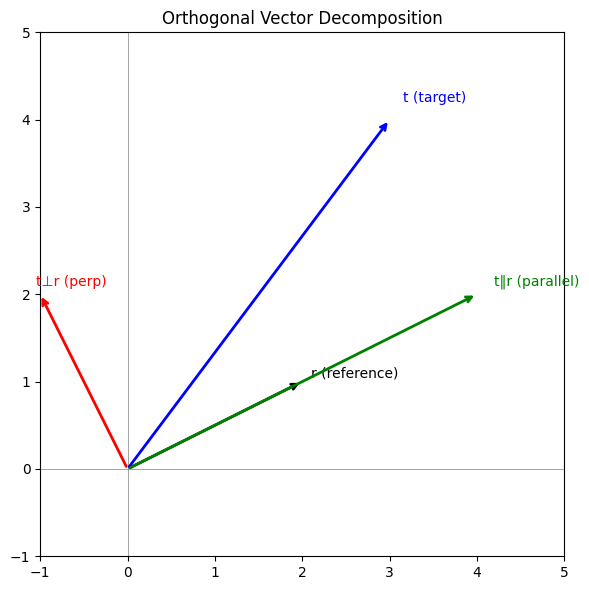

In [11]:
import matplotlib.pyplot as plt

# Orthogonal vector decomposition
t = np.array([3, 4], dtype=float)  # target vector
r = np.array([2, 1], dtype=float)  # reference vector

# Compute the scalar beta (projection coefficient)
beta = np.dot(r, t) / np.dot(r, r)

# Compute parallel and perpendicular components
t_parallel = beta * r
t_perp     = t - t_parallel

print(f'Target vector t:         {t}')
print(f'Reference vector r:      {r}')
print(f'Projection scalar beta:  {beta:.4f}')
print(f'Parallel component:      {t_parallel}')
print(f'Perpendicular component: {t_perp}')

# Verify: t_parallel + t_perp should equal t
print(f'\nReconstruction check: {np.allclose(t_parallel + t_perp, t)}')

# Verify orthogonality: dot product of t_perp and r should be ~0
print(f'Orthogonality check:  {np.isclose(np.dot(t_perp, r), 0)}')

# Visualization
_, ax = plt.subplots(figsize=(7, 6))
origin = np.zeros(2)
vectors = {'t (target)': t, 'r (reference)': r,
           't‖r (parallel)': t_parallel, 't⊥r (perp)': t_perp}
colors  = ['blue', 'black', 'green', 'red']
for (label, vec), col in zip(vectors.items(), colors):
    ax.annotate('', xytext=origin, xy=vec,
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(vec[0]*1.05, vec[1]*1.05, label, color=col, fontsize=10)
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title('Orthogonal Vector Decomposition')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()